# Maximum Validation Accuracy: 96.66%

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Rescaling
import matplotlib.pyplot as plt

import keras,os
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten, Dropout
import numpy as np

In [2]:
# dataset_dir = '/kaggle/input/plant-leaf-dataset/Leaf Dataset'
dataset_dir = '/Users/sumitkumar/Desktop/VSCode/LPU/SEM2/AI/CNN/Project-Final/Leaf-Dataset'

In [3]:
batch_size = 16
img_height = 200
img_width = 300


In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.1,
    # color_mode='grayscale',
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.1,
    # color_mode='grayscale',
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 300 files belonging to 6 classes.
Using 270 files for training.
Found 300 files belonging to 6 classes.
Using 30 files for validation.


In [5]:
class_names = train_ds.class_names
class_names

['Basil', 'Chinar', 'Guava', 'Jamun', 'Lemon', 'Mango']

2026-04-25 12:02:19.447475: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


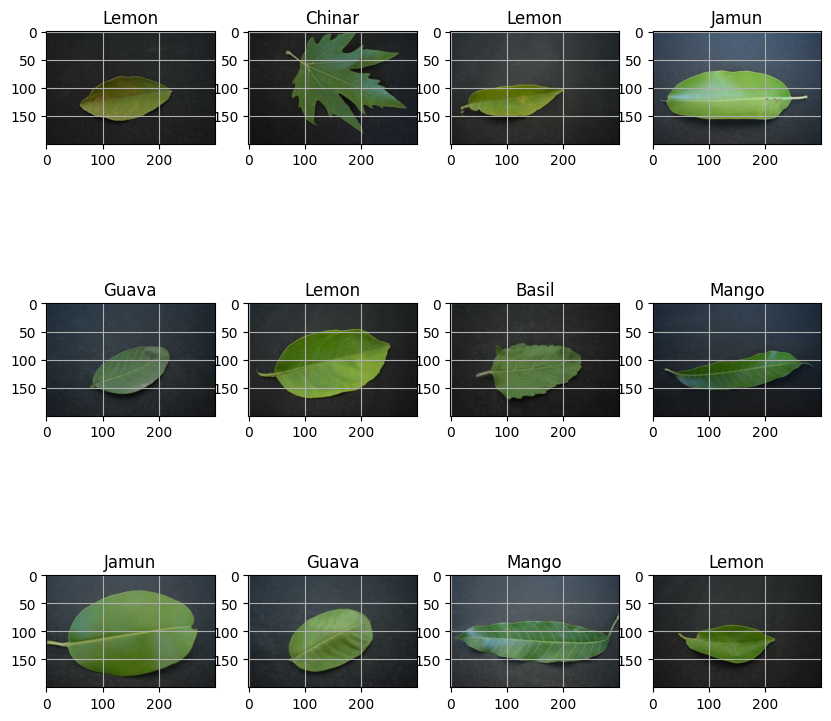

In [6]:
# plt.figure(figsize=(10, 10))
# for images, labels in train_ds.take(1):
#   for i in range(9):
#     ax = plt.subplot(3, 3, i + 1)
#     plt.imshow(images[i].numpy().astype("uint8"))
#     plt.title(class_names[labels[i]])
#     plt.axis("off")
    
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.grid(True)

In [7]:
# model = Sequential([
# Rescaling(1./255, input_shape=(img_height, img_width, 3)),
# Conv2D(3, 3, activation='relu'),
# MaxPooling2D(),
# Conv2D(3, 3, activation='relu'),
# MaxPooling2D(),
# # Conv2D(3, 3, activation='relu'),
# # MaxPooling2D(),
# # Dropout(0.2),
# Flatten(),
# Dense(16, activation='relu'),
# Dense(16, activation='relu'),
# Dense(16, activation='relu'),
# Dropout(0.5),
# Dense(len(class_names), activation='softmax')
# ])


# Rewritten Model
model = Sequential([
Rescaling(1./255, input_shape=(img_height, img_width, 3)),
Conv2D(3, 3, activation='relu'),
MaxPooling2D(),
Conv2D(3, 3, activation='relu'),
MaxPooling2D(),
# Conv2D(3, 3, activation='relu'),
# MaxPooling2D(),
# Dropout(0.2),
Flatten(),
Dense(16, activation='relu'),
Dense(32, activation='relu'),
Dense(64, activation='relu'),
Dropout(0.5),
Dense(len(class_names), activation='softmax')
])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE),
              metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 198, 298, 3)    │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 149, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 147, 3)     │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 73, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10512)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       168,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,422 (669.62 KB)

 Trainable params: 171,422 (669.62 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
epochs = 30
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs = epochs
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1741 - loss: 1.7906 - val_accuracy: 0.2667 - val_loss: 1.7825
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2148 - loss: 1.7708 - val_accuracy: 0.3000 - val_loss: 1.7172
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3074 - loss: 1.6382 - val_accuracy: 0.3667 - val_loss: 1.4520
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3889 - loss: 1.4302 - val_accuracy: 0.4667 - val_loss: 1.2887
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5556 - loss: 1.1916 - val_accuracy: 0.6333 - val_loss: 0.9574
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6889 - loss: 0.8759 - val_accuracy: 0.6667 - val_loss: 0.8216
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8407 - loss: 0.5377 - val_accuracy: 0.8333 - val_loss: 0.5493
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8519 - loss: 0.4216 - val_accuracy: 0.7667 - v

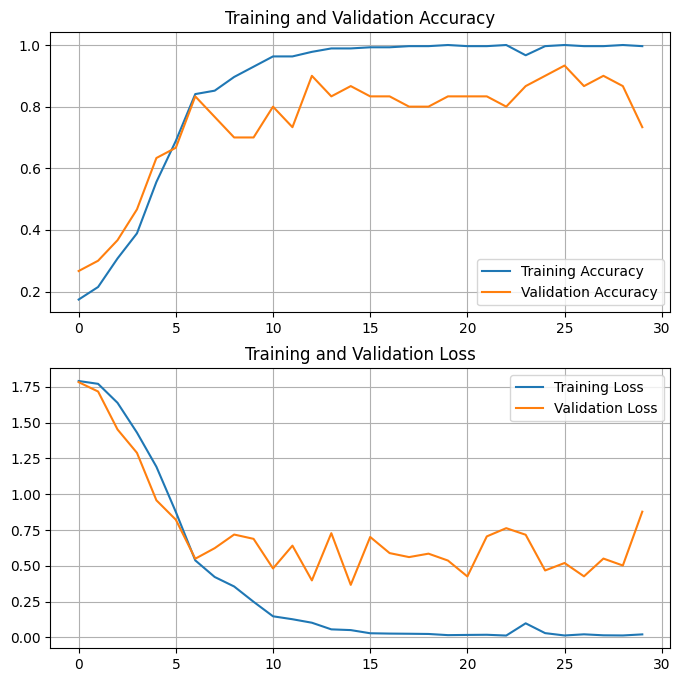

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [12]:
# Display the maximum validation accuracy
print(f"Maximum Validation Accuracy: {max(val_acc)*100:.2f}%")

Maximum Validation Accuracy: 93.33%


In [13]:
# Display the minimum validation loss
print(f"Maximum Validation Loss: {min(val_loss)*100:.2f}%")

Maximum Validation Loss: 36.66%


In [14]:
test_loss, test_acc = model.evaluate(train_ds)
print(f'Test Loss: {test_loss * 100:.2f}%')
print(f'Test Accuracy: {test_acc * 100:.2f}%')

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 5.6369e-04
Test Loss: 0.06%
Test Accuracy: 100.00%


In [15]:
print(model.evaluate(val_ds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7333 - loss: 0.8778
[0.877755343914032, 0.7333333492279053]


In [16]:
# import joblib

In [17]:
# joblib.dump(model, 'model.pkl')

In [18]:
# from google.colab import files
# files.download('model.pkl')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


2026-04-25 12:02:40.511715: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


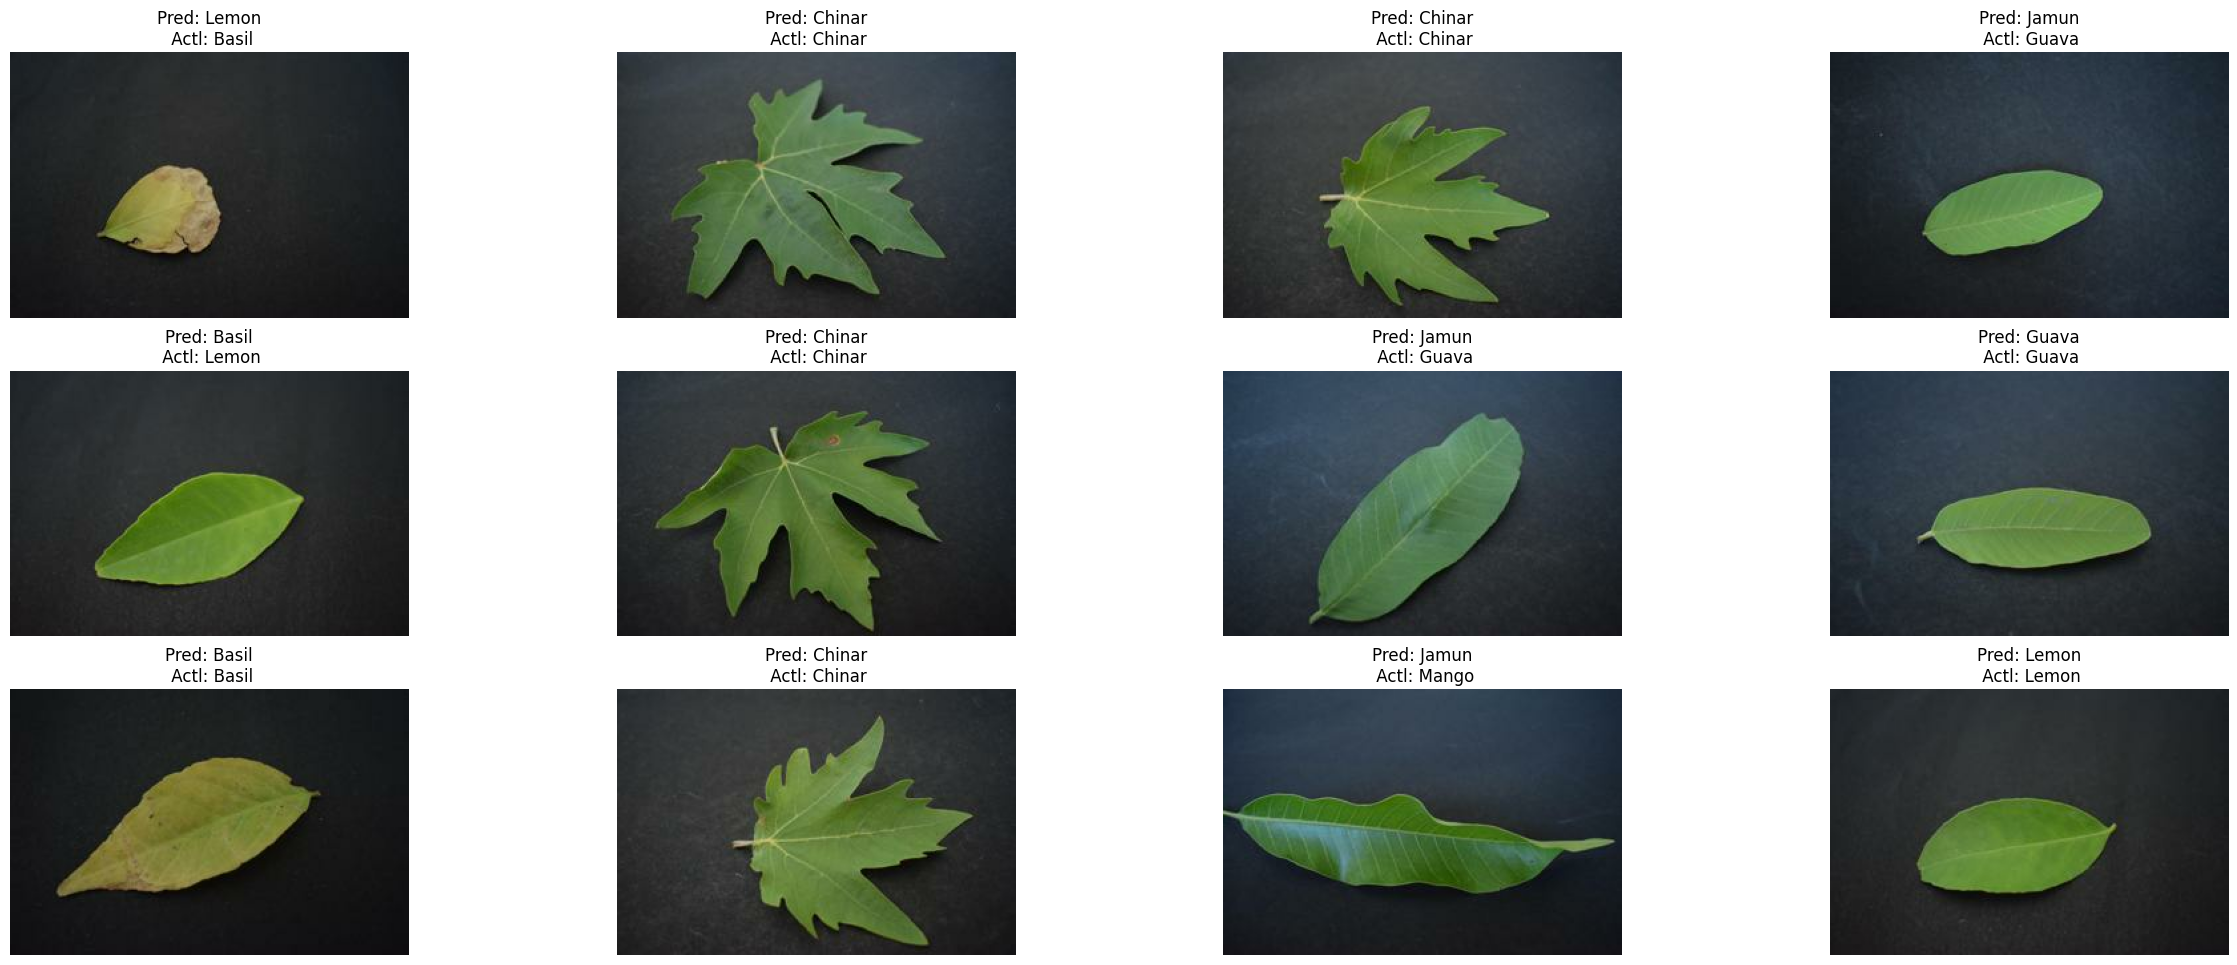

In [19]:
AccuracyVector = []
plt.figure(figsize=(30, 20))
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predlabel = []
    prdlbl = []
    
    for mem in predictions:
        predlabel.append(class_names[np.argmax(mem)])
        prdlbl.append(np.argmax(mem))
    
    AccuracyVector = np.array(prdlbl) == labels
    for i in range(12):
        ax = plt.subplot(5, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title('Pred: '+ predlabel[i] + '\n Actl: '+ class_names[labels[i]])
        plt.axis('off')
        plt.grid(True)

In [20]:
# pip install pyyaml h5py  # Required to save models in HDF5 format

In [21]:
# model.save('plantclassificationmodelUpdated.h5',include_optimizer=True)